In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from genkit.datasets import fetch_synthetic_data
from genkit.diffusion import DDPMEps
from genkit.flow import GaussianFlowLinear
from genkit.model import LightNet
from genkit.training import train
from genkit.plotting import PRETTY_RCPARAMS


plt.rcParams.update(PRETTY_RCPARAMS)


In [2]:
dim = 1
n_samples = 2**11
n_steps = 2**6
batch_size = 2**6
n_epochs = 2**9
lr = 1e-3
width = 2**6
n_blocks = 3
device = "cuda" if torch.cuda.is_available() else "cpu"
fdtype = torch.float32
idtype = torch.int32

In [3]:
x_train, _, x_ref = fetch_synthetic_data("balanced_bimodal_gaussian",
                                          n_samples=n_samples, dim=dim,
                                          device=device, dtype=fdtype)

kwargs = dict(target_data=x_train, batch_size=batch_size, n_epochs=n_epochs, lr=lr, device=device)
net_kwargs = dict(width=width, n_blocks=n_blocks)

In [ ]:
def plot_path_panel(generator, fig, subplot_spec, title, n_plot_samples=100, color="tab:blue"):
    _, l_x = generator._sample_all_traj(n_plot_samples)
    X = np.stack([x.detach().cpu().numpy() for x in l_x], axis=0)[..., 0].T

    n_samples, n_local_steps = X.shape
    t = np.arange(1, n_local_steps + 1)
    ymin, ymax = np.quantile(X, [0.01, 0.99])

    inner = subplot_spec.subgridspec(1, 3, width_ratios=[1, 2.5, 1], wspace=0.0)
    ax_l = fig.add_subplot(inner[0, 0])
    ax = fig.add_subplot(inner[0, 1], sharey=ax_l)
    ax_r = fig.add_subplot(inner[0, 2], sharey=ax_l)

    for x in X:
        ax.plot(t, x, lw=0.5, alpha=0.2, color=color)

    ax.set_title(title)
    ax.set(xlim=(1, n_local_steps), ylim=(ymin, ymax), xlabel="T")
    ax.set_xticks([1, n_local_steps], [1, n_local_steps])
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", length=0)

    for vals, hist_ax, invert in [
        (X[:, 0], ax_l, True),
        (X[:, -1], ax_r, False),
    ]:
        hist_ax.hist(vals, bins=20, orientation="horizontal", color=color, alpha=0.3)
        if invert:
            hist_ax.invert_xaxis()

        hist_ax.set_xticks([])
        hist_ax.spines["left"].set_visible(False)
        hist_ax.spines["bottom"].set_visible(False)
        hist_ax.tick_params(axis="both", left=False, bottom=False, labelleft=False, labelbottom=False)

    return ax_l, ax, ax_r


In [7]:
model_specs = [
    ("DDPMEps", DDPMEps, "tab:blue"),
    ("GaussianFlowLinear", GaussianFlowLinear, "tab:orange"),
]

trained_generators = {}
for title, model_cls, color in model_specs:
    net = LightNet(dim=dim, **net_kwargs).to(device=device, dtype=fdtype)
    kwargs["generative_model"] = model_cls(
        net=net,
        dim=dim,
        n_steps=n_steps,
        device=device,
        fdtype=fdtype,
        idtype=idtype,
    )
    generator, _ = train(**kwargs)
    trained_generators[title] = {"generator": generator, "color": color}


/tmp/ipykernel_379895/2607335901.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.1)


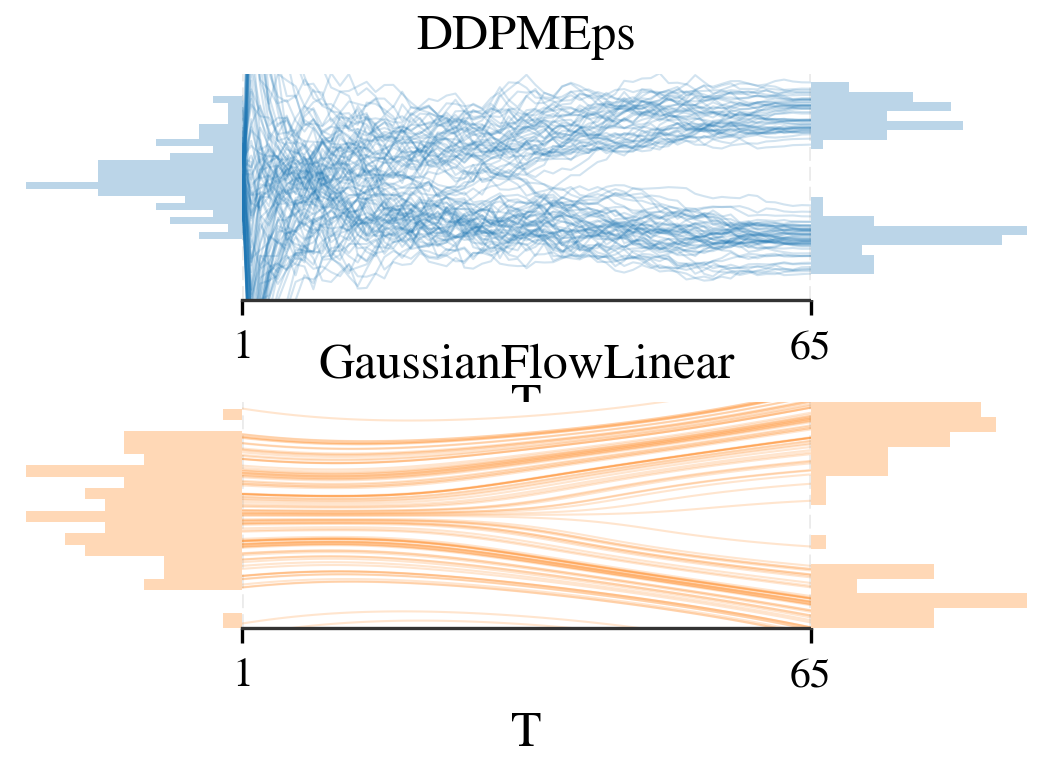

In [8]:
fig = plt.figure(figsize=(4.4, 2.4), dpi=300)
outer = fig.add_gridspec(len(model_specs), 1, hspace=0.45)

for row, (title, _, _) in enumerate(model_specs):
    model_plot = trained_generators[title]
    plot_path_panel(
        model_plot["generator"],
        fig,
        outer[row],
        title=title,
        color=model_plot["color"],
    )

fig.tight_layout(pad=0.1)
